In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/glasses-detection"

print(os.listdir(dataset_path))

['README.roboflow.txt', 'README.dataset.txt', 'valid', 'test', 'train']


In [ ]:
!pip install pycocotools

In [ ]:
import os
import torch
import torchvision

from PIL import Image

from torch.utils.data import Dataset, DataLoader

from torchvision.models.detection import fasterrcnn_resnet50_fpn

from torchvision.transforms import functional as F

from pycocotools.coco import COCO

In [ ]:
class GlassesDataset(Dataset):

    def __init__(self, root, annotation):

        self.root = root

        self.coco = COCO(annotation)

        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):

        image_id = self.ids[index]

        image_info = self.coco.loadImgs(image_id)[0]

        image_path = os.path.join(
            self.root,
            image_info['file_name']
        )

        image = Image.open(image_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=image_id)

        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []

        for ann in anns:

            x, y, w, h = ann['bbox']

            boxes.append([x, y, x+w, y+h])

            labels.append(1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        image = F.to_tensor(image)

        return image, target

    def __len__(self):

        return len(self.ids)

In [ ]:
train_dataset = GlassesDataset(
    root="/content/drive/MyDrive/glasses-detection/train",
    annotation="/content/drive/MyDrive/glasses-detection/train/_annotations.coco.json"
)

valid_dataset = GlassesDataset(
    root="/content/drive/MyDrive/glasses-detection/valid",
    annotation="/content/drive/MyDrive/glasses-detection/valid/_annotations.coco.json"
)

loading annotations into memory...
Done (t=0.74s)
creating index...
index created!
loading annotations into memory...
Done (t=0.34s)
creating index...
index created!


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

In [ ]:
model = fasterrcnn_resnet50_fpn(pretrained=True)

num_classes = 2

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 174MB/s]


In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
num_epochs = 10

start_epoch = 0

checkpoint_path = "/content/drive/MyDrive/checkpoint.pth"

# =========================
# LOAD CHECKPOINT IF EXISTS
# =========================

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['model_state'])

    optimizer.load_state_dict(checkpoint['optimizer_state'])

    start_epoch = checkpoint['epoch']

    print(f"Resuming from Epoch {start_epoch}")

# =========================
# TRAINING LOOP
# =========================

for epoch in range(start_epoch, num_epochs):

    model.train()

    epoch_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader):

        images = list(image.to(device) for image in images)

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()

        losses.backward()

        optimizer.step()

        epoch_loss += losses.item()

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Batch [{batch_idx+1}] "
            f"Loss: {losses.item():.4f}"
        )

    print(f"Epoch {epoch+1} Total Loss: {epoch_loss:.4f}")

    # =========================
    # SAVE CHECKPOINT
    # =========================

    torch.save({

        'epoch': epoch + 1,

        'model_state': model.state_dict(),

        'optimizer_state': optimizer.state_dict()

    }, checkpoint_path)

    print("Checkpoint Saved")

# =========================
# FINAL MODEL SAVE
# =========================

torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/faster_rcnn_glasses.pth"
)

print("Final Model Saved")

Resuming from Epoch 10
Final Model Saved


In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/faster_rcnn_glasses.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
model = fasterrcnn_resnet50_fpn(pretrained=False)

num_classes = 2

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/faster_rcnn_glasses.pth")
)

model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [ ]:
import os

base = "/content/drive/MyDrive/glasses-detection"

print("TRAIN")
print(os.listdir(base + "/train"))

print("\nVALID")
print(os.listdir(base + "/valid"))

print("\nTEST")
print(os.listdir(base + "/test"))

TRAIN
['13_jpg.rf.c76db5e63778e1bc03b96289b9dc4fc3.jpg', '91_jpg.rf.8f346e5eccc565ca12d4fb28a7a292ad.jpg', '78_jpg.rf.14a00be0a7ccaaba0a098b2ace09c3ba.jpg', '54_jpg.rf.1b686bc88738af7f23d28590ef9151c0.jpg', '18_jpg.rf.8d1a7fe0b154d28cdfe646c38ca4db68.jpg', '69_jpg.rf.7187dc657d852d7e86b60f590c30abe4.jpg', 'images-34-_jpeg_jpg.rf.741a161a9d426c0c86578d098c165864.jpg', '16_jpg.rf.8b620522d6b9e13e234b1a945574d9cd.jpg', '3_jpg.rf.c359977750a0bda1144710d1b1b5b3b9.jpg', '88_jpg.rf.4d60063198c768c919b01990c6e67cb6.jpg', '11_jpg.rf.32f11b8ee2995a564c3bbb60425e355f.jpg', '83_jpg.rf.e1dfaf76e06b63e5295787bc3216b236.jpg', '78_jpg.rf.8f8b256fa1e6d28fd0cf41e60afc483d.jpg', '15_jpg.rf.c1d10be8d38f63559837b525c62941e8.jpg', '68_jpg.rf.7b0d7acf7deea2cebec3bb289ca81757.jpg', '56_jpg.rf.258233a0b34c9a416c8d63de9e9bb0e3.jpg', '92_jpg.rf.bcc3408f36df1e5332c78c5704e41591.jpg', '45_jpg.rf.e53a51165d9c178946aca33101fcef83.jpg', '62_jpg.rf.b865a1d2911081aab36716a604de17bf.jpg', '52_jpg.rf.3513e41c6149fc1da2dd

In [ ]:
import json

with open("/content/drive/MyDrive/glasses-detection/test/_annotations.coco.json") as f:
    coco = json.load(f)

print(coco["categories"])

[{'id': 0, 'name': 'Bounding-Boxes-ztic', 'supercategory': 'none'}, {'id': 1, 'name': '------------------------------', 'supercategory': 'Bounding-Boxes-ztic'}, {'id': 2, 'name': 'None', 'supercategory': 'Bounding-Boxes-ztic'}, {'id': 3, 'name': 'This dataset was exported via roboflow-com on November 12- 2023 at 8-41 AM GMT', 'supercategory': 'Bounding-Boxes-ztic'}, {'id': 4, 'name': 'glasses - v1 2023-11-12 4-37pm', 'supercategory': 'Bounding-Boxes-ztic'}]


In [ ]:
import json

with open("/content/drive/MyDrive/glasses-detection/test/_annotations.coco.json") as f:
    coco = json.load(f)

print("===== CATEGORIES =====")

for c in coco["categories"]:
    print(c)

print("\n===== FIRST 10 ANNOTATIONS =====")

for a in coco["annotations"][:10]:
    print(a)

===== CATEGORIES =====
{'id': 0, 'name': 'Bounding-Boxes-ztic', 'supercategory': 'none'}
{'id': 1, 'name': '------------------------------', 'supercategory': 'Bounding-Boxes-ztic'}
{'id': 2, 'name': 'None', 'supercategory': 'Bounding-Boxes-ztic'}
{'id': 3, 'name': 'This dataset was exported via roboflow-com on November 12- 2023 at 8-41 AM GMT', 'supercategory': 'Bounding-Boxes-ztic'}
{'id': 4, 'name': 'glasses - v1 2023-11-12 4-37pm', 'supercategory': 'Bounding-Boxes-ztic'}

===== FIRST 10 ANNOTATIONS =====
{'id': 1, 'image_id': 0, 'category_id': 1, 'bbox': [225, 341, 208, 62], 'iscrowd': 0, 'area': 12896, 'segmentation': []}
{'id': 2, 'image_id': 1, 'category_id': 1, 'bbox': [226, 303, 298, 171], 'iscrowd': 0, 'area': 50958, 'segmentation': []}
{'id': 3, 'image_id': 2, 'category_id': 1, 'bbox': [93, 329, 149, 130], 'iscrowd': 0, 'area': 19370, 'segmentation': []}
{'id': 4, 'image_id': 2, 'category_id': 1, 'bbox': [239, 98, 135, 119], 'iscrowd': 0, 'area': 16065, 'segmentation': []}
{'

In [ ]:
import json
from collections import Counter

with open("/content/drive/MyDrive/glasses-detection/test/_annotations.coco.json") as f:
    coco = json.load(f)

counter = Counter()

for ann in coco["annotations"]:
    counter[ann["category_id"]] += 1

print(counter)

Counter({4: 15, 1: 13, 3: 3})


In [ ]:
print(model.roi_heads.box_predictor.cls_score.out_features)

2


In [ ]:
import json

with open("/content/drive/MyDrive/glasses-detection/test/_annotations.coco.json") as f:
    coco = json.load(f)

print("Images:", len(coco["images"]))
print("Annotations:", len(coco["annotations"]))

Images: 21
Annotations: 31


In [ ]:
import json

with open("/content/drive/MyDrive/glasses-detection/test/_annotations.coco.json") as f:
    coco = json.load(f)

print("Images:", len(coco["images"]))
print("Annotations:", len(coco["annotations"]))

Images: 21
Annotations: 31


In [ ]:
!pip install pycocotools -q

In [ ]:
import os
import json
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import defaultdict

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None
)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    2
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/faster_rcnn_glasses.pth",
        map_location=device
    )
)

model.to(device)

model.eval()

print("Model Loaded")

Device: cuda
Model Loaded


In [ ]:
ANNOTATION_FILE = \
"/content/drive/MyDrive/glasses-detection/test/_annotations.coco.json"

IMAGE_FOLDER = \
"/content/drive/MyDrive/glasses-detection/test"

with open(ANNOTATION_FILE) as f:
    coco = json.load(f)

print("Images:", len(coco["images"]))
print("Annotations:", len(coco["annotations"]))

Images: 21
Annotations: 31


In [ ]:
train_losses = []

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0

    for images, targets in train_loader:

        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()

        losses.backward()

        optimizer.step()

        epoch_loss += losses.item()

    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

torch.save(train_losses,
           "/content/drive/MyDrive/detection_losses.pth")

In [ ]:
def calculate_iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    areaA = (
        (boxA[2]-boxA[0]) *
        (boxA[3]-boxA[1])
    )

    areaB = (
        (boxB[2]-boxB[0]) *
        (boxB[3]-boxB[1])
    )

    union = areaA + areaB - inter

    if union == 0:
        return 0

    return inter / union

In [ ]:
gt_boxes = defaultdict(list)

for ann in coco["annotations"]:

    img_id = ann["image_id"]

    x, y, w, h = ann["bbox"]

    gt_boxes[img_id].append(
        [x, y, x+w, y+h]
    )

In [ ]:
y_true = []
y_pred = []

ious = []

for img_info in coco["images"]:

    img_id = img_info["id"]

    path = os.path.join(
        IMAGE_FOLDER,
        img_info["file_name"]
    )

    image = Image.open(path).convert("RGB")

    tensor = F.to_tensor(image)

    tensor = tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(tensor)

    pred_boxes = output[0]["boxes"].cpu().numpy()

    scores = output[0]["scores"].cpu().numpy()

    pred_boxes = [
        b for b,s
        in zip(pred_boxes,scores)
        if s > 0.5
    ]

    gt = gt_boxes[img_id]

    matched = False

    for gt_box in gt:

        best_iou = 0

        for pred_box in pred_boxes:

            iou = calculate_iou(
                gt_box,
                pred_box
            )

            best_iou = max(
                best_iou,
                iou
            )

        ious.append(best_iou)

        y_true.append(1)

        if best_iou > 0.5:

            y_pred.append(1)

            matched = True

        else:

            y_pred.append(0)

    if len(gt)==0 and len(pred_boxes)>0:

        y_true.append(0)

        y_pred.append(1)

In [ ]:
precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

avg_iou = np.mean(ious)

print("\nRESULTS")

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("Average IoU :", avg_iou)


RESULTS
Precision : 1.0
Recall : 0.967741935483871
F1 Score : 0.9836065573770492
Average IoU : 0.8178458079215019


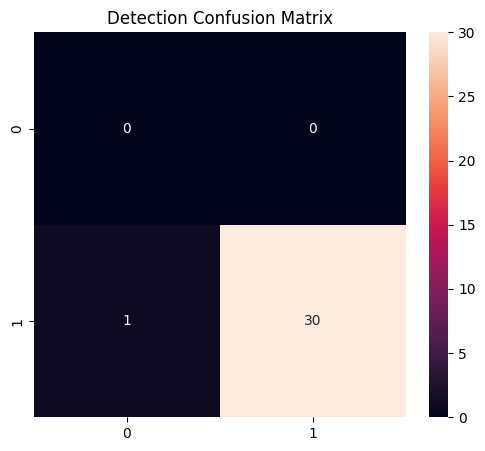

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Detection Confusion Matrix"
)

plt.savefig(
    "confusion_matrix.png"
)

plt.show()

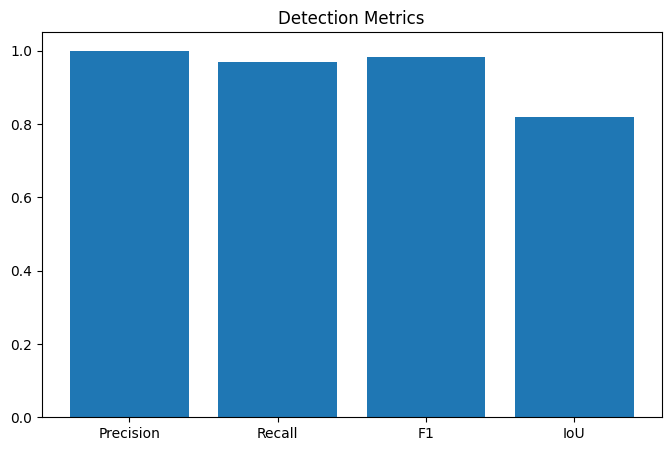

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Precision",
     "Recall",
     "F1",
     "IoU"],
    [
        precision,
        recall,
        f1,
        avg_iou
    ]
)

plt.title(
    "Detection Metrics"
)

plt.savefig(
    "metrics_graph.png"
)

plt.show()

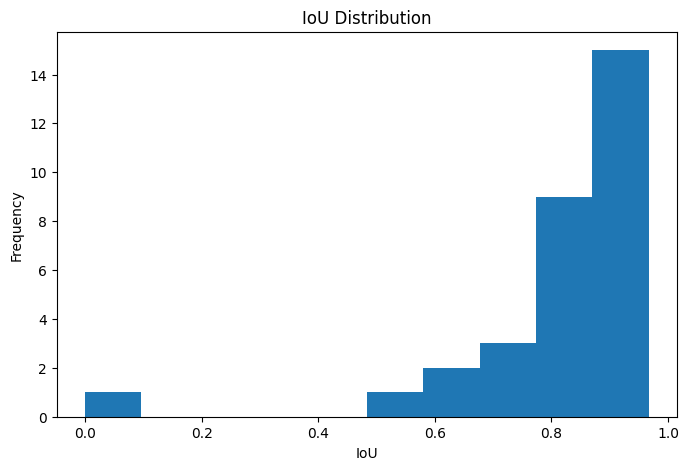

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    ious,
    bins=10
)

plt.title(
    "IoU Distribution"
)

plt.xlabel("IoU")

plt.ylabel("Frequency")

plt.savefig(
    "iou_histogram.png"
)

plt.show()

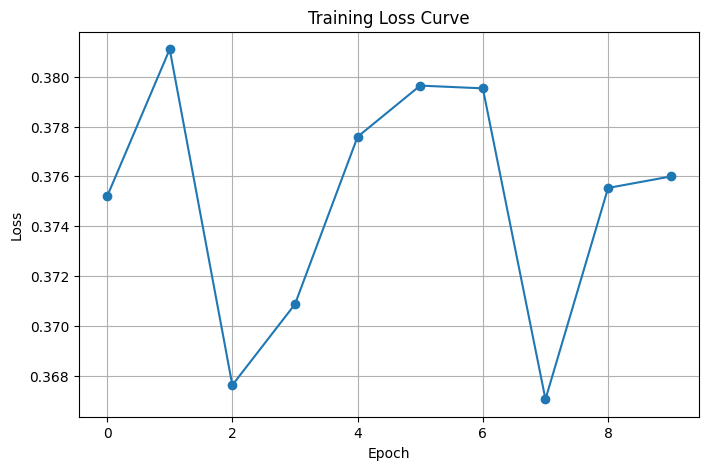

In [ ]:
losses = torch.load(
    "/content/drive/MyDrive/detection_losses.pth"
)

plt.figure(figsize=(8,5))

plt.plot(
    losses,
    marker="o"
)

plt.title(
    "Training Loss Curve"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.grid()

plt.savefig(
    "loss_curve.png"
)

plt.show()

Device: cuda
Model Loaded Successfully


Saving Glasses.jpg to Glasses.jpg


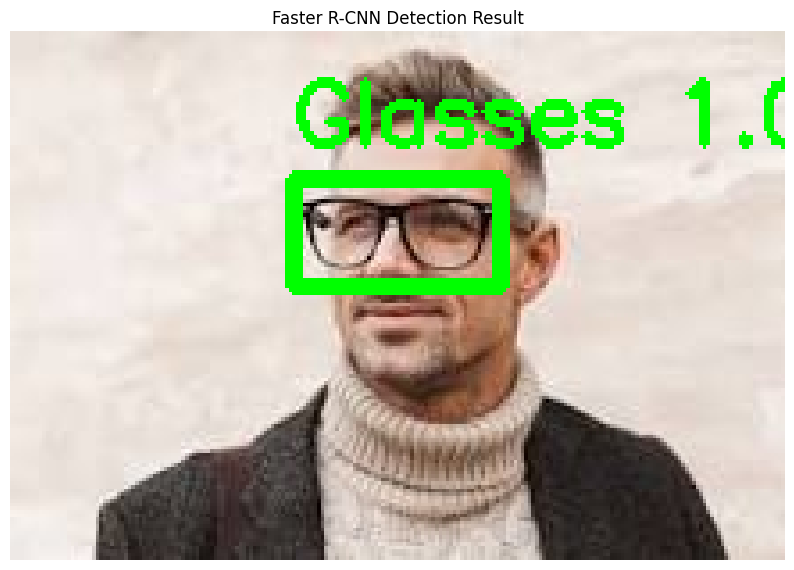

In [ ]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# ======================================
# GPU CHECK
# ======================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ======================================
# LOAD MODEL
# ======================================

num_classes = 2

model = fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None
)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/faster_rcnn_glasses.pth",
        map_location=device
    )
)

model.to(device)

model.eval()

print("Model Loaded Successfully")

# ======================================
# UPLOAD IMAGE
# ======================================

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# ======================================
# READ IMAGE
# ======================================

image = Image.open(image_path).convert("RGB")

image_np = np.array(image)

image_tensor = F.to_tensor(image)

image_tensor = image_tensor.unsqueeze(0).to(device)

# ======================================
# PREDICTION
# ======================================

with torch.no_grad():

    predictions = model(image_tensor)

# ======================================
# DRAW BOXES
# ======================================

boxes = predictions[0]["boxes"].cpu()

scores = predictions[0]["scores"].cpu()

for i in range(len(boxes)):

    confidence = scores[i].item()

    if confidence > 0.5:

        x1, y1, x2, y2 = boxes[i].int().numpy()

        cv2.rectangle(
            image_np,
            (x1, y1),
            (x2, y2),
            (0,255,0),
            3
        )

        cv2.putText(
            image_np,
            f"Glasses {confidence:.2f}",
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,0),
            2
        )

# ======================================
# SHOW RESULT
# ======================================

plt.figure(figsize=(10,10))

plt.imshow(image_np)

plt.axis("off")

plt.title("Faster R-CNN Detection Result")

plt.show()

Model Loaded Successfully


Saving 1.jpeg to 1.jpeg


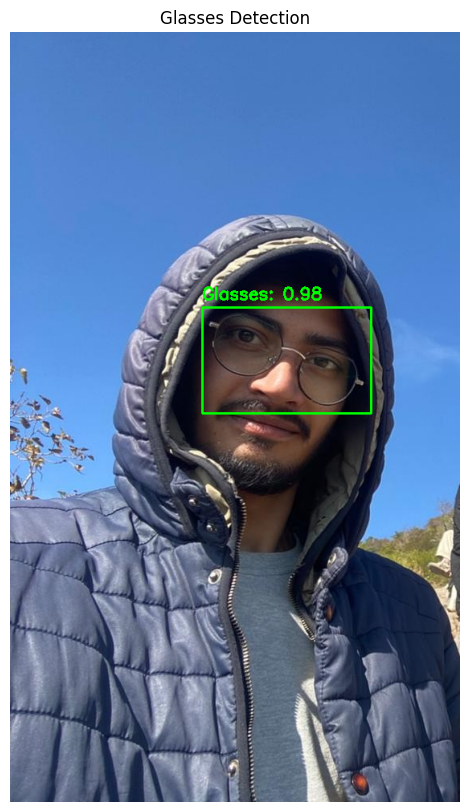

In [ ]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from google.colab import files

# =========================
# LOAD MODEL
# =========================

num_classes = 2

model = fasterrcnn_resnet50_fpn(pretrained=False)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/faster_rcnn_glasses.pth",
        map_location=torch.device('cpu')
    )
)

model.eval()

print("Model Loaded Successfully")

# =========================
# UPLOAD IMAGE
# =========================

uploaded = files.upload()

# Get uploaded image name
image_path = list(uploaded.keys())[0]

# =========================
# READ IMAGE
# =========================

image = Image.open(image_path).convert("RGB")

image_np = np.array(image)

# Convert to tensor
image_tensor = F.to_tensor(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

# =========================
# PREDICTION
# =========================

with torch.no_grad():

    predictions = model(image_tensor)

# =========================
# DRAW BOUNDING BOXES
# =========================

boxes = predictions[0]['boxes']
scores = predictions[0]['scores']

for i in range(len(boxes)):

    confidence = scores[i].item()

    # confidence threshold
    if confidence > 0.5:

        x1, y1, x2, y2 = boxes[i].int().numpy()

        # Draw rectangle
        cv2.rectangle(
            image_np,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Put confidence text
        cv2.putText(
            image_np,
            f"Glasses: {confidence:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0,255,0),
            2
        )

# =========================
# SHOW RESULT
# =========================

plt.figure(figsize=(10,10))

plt.imshow(image_np)

plt.axis("off")

plt.title("Glasses Detection")

plt.show()

Model Loaded Successfully


Saving Glasses.jpg to Glasses.jpg


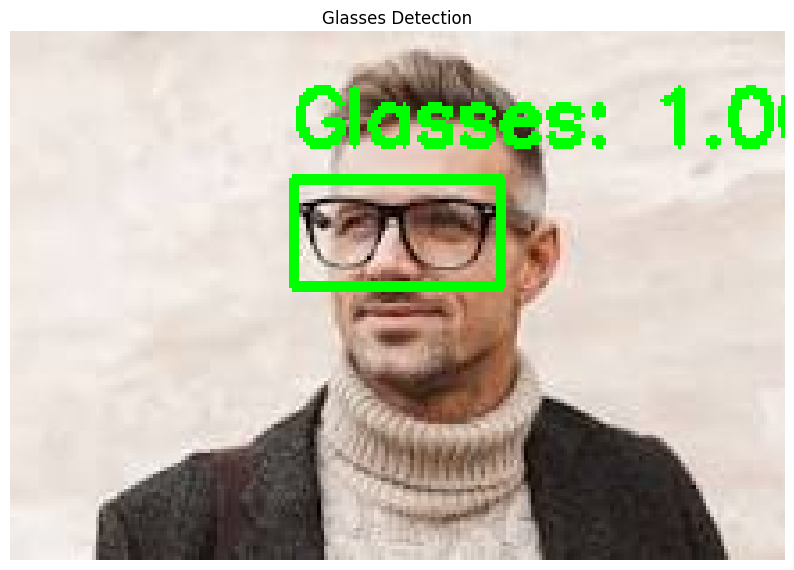

In [ ]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from google.colab import files

# =========================
# LOAD MODEL
# =========================

num_classes = 2

model = fasterrcnn_resnet50_fpn(pretrained=False)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/faster_rcnn_glasses.pth",
        map_location=torch.device('cpu')
    )
)

model.eval()

print("Model Loaded Successfully")

# =========================
# UPLOAD IMAGE
# =========================

uploaded = files.upload()

# Get uploaded image name
image_path = list(uploaded.keys())[0]

# =========================
# READ IMAGE
# =========================

image = Image.open(image_path).convert("RGB")

image_np = np.array(image)

# Convert to tensor
image_tensor = F.to_tensor(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

# =========================
# PREDICTION
# =========================

with torch.no_grad():

    predictions = model(image_tensor)

# =========================
# DRAW BOUNDING BOXES
# =========================

boxes = predictions[0]['boxes']
scores = predictions[0]['scores']

for i in range(len(boxes)):

    confidence = scores[i].item()

    # confidence threshold
    if confidence > 0.5:

        x1, y1, x2, y2 = boxes[i].int().numpy()

        # Draw rectangle
        cv2.rectangle(
            image_np,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Put confidence text
        cv2.putText(
            image_np,
            f"Glasses: {confidence:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0,255,0),
            2
        )

# =========================
# SHOW RESULT
# =========================

plt.figure(figsize=(10,10))

plt.imshow(image_np)

plt.axis("off")

plt.title("Glasses Detection")

plt.show()

Model Loaded Successfully


Saving no glasses.jpg to no glasses.jpg


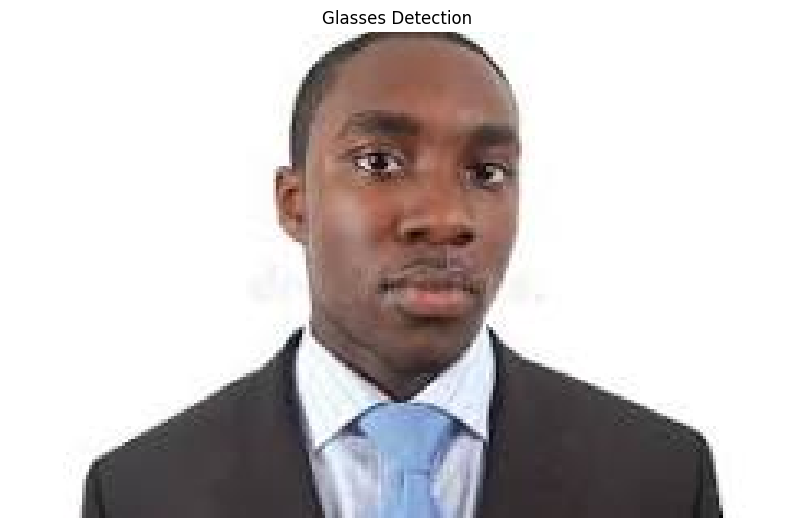

In [ ]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from google.colab import files

# =========================
# LOAD MODEL
# =========================

num_classes = 2

model = fasterrcnn_resnet50_fpn(pretrained=False)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/faster_rcnn_glasses.pth",
        map_location=torch.device('cpu')
    )
)

model.eval()

print("Model Loaded Successfully")

# =========================
# UPLOAD IMAGE
# =========================

uploaded = files.upload()

# Get uploaded image name
image_path = list(uploaded.keys())[0]

# =========================
# READ IMAGE
# =========================

image = Image.open(image_path).convert("RGB")

image_np = np.array(image)

# Convert to tensor
image_tensor = F.to_tensor(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

# =========================
# PREDICTION
# =========================

with torch.no_grad():

    predictions = model(image_tensor)

# =========================
# DRAW BOUNDING BOXES
# =========================

boxes = predictions[0]['boxes']
scores = predictions[0]['scores']

for i in range(len(boxes)):

    confidence = scores[i].item()

    # confidence threshold
    if confidence > 0.5:

        x1, y1, x2, y2 = boxes[i].int().numpy()

        # Draw rectangle
        cv2.rectangle(
            image_np,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Put confidence text
        cv2.putText(
            image_np,
            f"Glasses: {confidence:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0,255,0),
            2
        )

# =========================
# SHOW RESULT
# =========================

plt.figure(figsize=(10,10))

plt.imshow(image_np)

plt.axis("off")

plt.title("Glasses Detection")

plt.show()

Model Loaded Successfully


Saving 20260321_130202.jpg to 20260321_130202.jpg


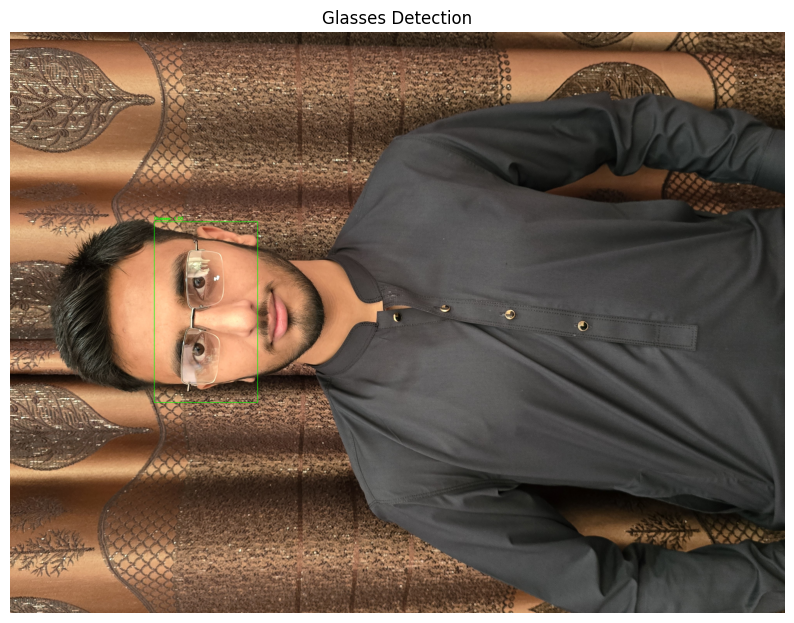

In [ ]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from google.colab import files

# =========================
# LOAD MODEL
# =========================

num_classes = 2

model = fasterrcnn_resnet50_fpn(pretrained=False)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/faster_rcnn_glasses.pth",
        map_location=torch.device('cpu')
    )
)

model.eval()

print("Model Loaded Successfully")

# =========================
# UPLOAD IMAGE
# =========================

uploaded = files.upload()

# Get uploaded image name
image_path = list(uploaded.keys())[0]

# =========================
# READ IMAGE
# =========================

image = Image.open(image_path).convert("RGB")

image_np = np.array(image)

# Convert to tensor
image_tensor = F.to_tensor(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

# =========================
# PREDICTION
# =========================

with torch.no_grad():

    predictions = model(image_tensor)

# =========================
# DRAW BOUNDING BOXES
# =========================

boxes = predictions[0]['boxes']
scores = predictions[0]['scores']

for i in range(len(boxes)):

    confidence = scores[i].item()

    # confidence threshold
    if confidence > 0.5:

        x1, y1, x2, y2 = boxes[i].int().numpy()

        # Draw rectangle
        cv2.rectangle(
            image_np,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Put confidence text
        cv2.putText(
            image_np,
            f"Glasses: {confidence:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0,255,0),
            2
        )

# =========================
# SHOW RESULT
# =========================

plt.figure(figsize=(10,10))

plt.imshow(image_np)

plt.axis("off")

plt.title("Glasses Detection")

plt.show()